# Fine-tuning del modelo UNI para el dataset PatchCamelyon

En este notebook se pretende hacer uso del modelo preentrenado UNI, disponible en HuggingFace y accesible a través de Pytorch para la
clasificación binaria de las imágrnes histológicas en:
- Tejido sano (clase 0) o
- Metástasis de de cáncer de mama en ganglios linfáticos (clase 1)


# Init

In [35]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, recall_score, roc_auc_score, classification_report, confusion_matrix, precision_score
from PIL import Image
import timm
from huggingface_hub import login
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
from torch.utils.data import Subset, DataLoader

Nos aseguramos de que la GPU es captada por la librería Pytorch:

In [17]:
print(f"Version de Pytorch usada: {torch.__version__}")
print(f"GPU disponible: {torch.backends.mps.is_available()}")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

Version de Pytorch usada: 2.8.0
GPU disponible: True


Creamos la clase PathCamelyonDataset para la extracción de imágenes de los ficheros h5py leídos

In [22]:
class PatchCamelyonDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.x_data = X
        self.y_data = y
        self.transform = transform
    
    def __len__(self):
        return len(self.x_data['x'])
    
    def __getitem__(self, idx):
        img = self.x_data['x'][idx]
        label = self.y_data['y'][idx]

        img = Image.fromarray(img)
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(label.squeeze(), dtype=torch.float32)

        return img, label

In [38]:

def run_epoch_metrics(loss, dataset_size, y_true, y_score):
    """
    Función para generar las metricas mostradas durante la ejecución de cada epoch y dataset (train o validacion)
    Input:
        loss = Valor de la función de pérdida
        dataset_size = tamaño del dataset
        y_true = etiquetas reales para los ejemplos de entrenamiento
        y_score = probabilidad predicha por el modelo para dichos ejemplos
    Output:
        Diccionario que contiene las siguientes métricas de la epoch:
        loss: valor de la función de pérdida
        accuracy: exactitud
        Recall: porcentaje de predicciones de la clase 1 capturadas o predichas correctamente por el modelo
        auc: area bajo la curva ROC para esta epoch
    """
    y_pred = [1 if score >= 0.5 else 0 for score in y_score]
    epoch_loss = loss / dataset_size
    epoch_acc = accuracy_score(y_true, y_pred)
    epoch_recall = recall_score(y_true, y_pred, zero_division=0)

    epoch_auc = roc_auc_score(y_true, y_score)

    sol = {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "recall": epoch_recall,
        "auc": epoch_auc
    }
    return sol


def run_epoch_images(model, dataloader, loss_run, optimizer=None, epoch_label=None):
    """
    Esta función ejecuta los pasos Forward pass de una epoch para la fase de fine-tunning, con
    un batch de entrada que contiene las imágenes originales del dataset y las etiquetas de clase.
    Las imágenes son procesadas por el modelo completo UNI + classifier

    Input:
        model = modelo compelto, UNIClassifer
        dataloader = Data loader de Pytorch a través del cual se accede al dataset en batches
        loss_run = función de pérdida seleccionada para el proceso de optimización del modelo
        optimizer = optimizador. Si se proporciona un optimizador, la función entrena el modelo. Si es None, solo se evalúa 
        el modelo sin actualizar los parámetros.
        epoch_label = contador en formato string que muestra el avance del entrenamiento (epoch actual / total de epoch máximas a ejecutar)
    Output:
        Métricas obtenidas como salida de la llamada a run_epoch_metrics para esta epoch
    """
    is_train = optimizer is not None
    model.train(is_train)
    running_loss = 0.0
    y_true = []
    y_score = []

    mode = "train" if is_train else "valid"
    progress_label = epoch_label or f"{mode} batches"

    for images, labels in tqdm(dataloader, desc=progress_label, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = loss_run(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        running_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy().astype(int).tolist())
        y_score.extend(probs.detach().cpu().numpy().tolist())

    return run_epoch_metrics(running_loss, len(dataloader.dataset), y_true, y_score)

def extract_features(encoder, dataloader, device, split_name):
    """
    Función que a partir de las imágenes originales utiliza el modelo UNI pre-entrenado para extraer los embeddings
    de las características generados por dicho modelo para el dataset proporcionado

    En esta función solo se hace uso de los bloques convolucionales de la red UNI (es decir todo el modelo menos la capa clasificadora)
    que está congelada, haciendo un forward-pass o inferencia.

    Input:
        encoder = parte del modelo encoder encargada de generar los embeddings.
        dataloader = DataLoader que retorna los lotes de imágenes del dataset.
        device = procesador donde se ejecuta la función. En este caso se le pasará la GPU disponible en el PC.
        extraída en el apartado Init.
        split_name = nombre del dataset con el que se hace la llamada (train o valiadcion). Es un string
        que se usa para imprimir el progreso

    Output:
        tupla que contiene:
        - X_features: Tensor con los embeddings para cada imagen
        - y_labels: etiqueta original asociada a cada imagen
    """
    from tqdm.auto import tqdm
    encoder.eval()
    features_list = []
    labels_list = []

    print(f"Extrayendo embeddings para {split_name} ({len(dataloader.dataset)} imagenes, {len(dataloader)} batches)...")
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"features:{split_name}", leave=False):
            images = images.to(device)
            features = encoder(images)
            features_list.append(features.cpu())
            labels_list.append(labels)

    return torch.cat(features_list), torch.cat(labels_list)


def run_epoch_classifier(head, dataloader, criterion, optimizer=None, epoch_label=None):
    """
    Función que ejecuta solo el bloque clasificador a partir de los embeddings de características
    extraidos por el modelo UNI (fase head-only)
    Input:
        head = bloque clasificador (head) del modelo
        dataloader: DataLoader que devuelve los lotes de embeddings y etiquetas para cada ejemplo del dataset
        criterion = función de pérdida seleccionada
        optimizer = optimizador para el entrenamiento. En caso de no ser provisto, estaremos en la parte de solo evaluar
        la red clasificadora
        epoch_label = Etiqueta con la epoch actual / numero total de epochs permitidas (string) para ser impresa
    Output:
        Métricas para esta epoch
    """
    is_train = optimizer is not None
    head.train(is_train)
    running_loss = 0.0
    y_true = []
    y_score = []

    mode = "train" if is_train else "valid"
    progress_label = epoch_label or f"{mode} head batches"
    for features, labels in tqdm(dataloader, desc=progress_label, leave=False):
        features = features.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_train):
            logits = head(features).squeeze(1)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = torch.sigmoid(logits)
        running_loss += loss.item() * features.size(0)
        y_true.extend(labels.detach().cpu().numpy().astype(int).tolist())
        y_score.extend(preds.detach().cpu().numpy().tolist())

    return run_epoch_metrics(running_loss, len(dataloader.dataset), y_true, y_score)

In [45]:
def model_evaluation(loader, device, model):
    """
    Funcion que realiza la inferencia para un dataset de entrada con el modelo que le pasemos
    Input:
        loader: DataLoader del dataset a evaluar
        device: procesador, en este caso la GPU del MAC
        model: modelo que se quiere usar para la evaluación
    Output:
        all_labels: etiquetas reales de las imágenes
        all_preds: predicciones para dichas imágenes
    """
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()

            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().astype(int).tolist())
    return all_labels, all_preds

Partiendo del Dataset PatchCamelyon (sin aplicar Data Augmentation), se realizan las siguientes transformaciones:
1.  Se redimensiona las imágenes a 224 x 224 que es el tamaño de entrada requerido para usar el modelo UNI
2.  Se almacenan en tensores para su fácil uso las imágenes
3.  Se normalizan al igual que se hizo para los pipelines de CNN

# Data Preparation

In [18]:
# Statistics obtained for training dataset during the CNN training
mean_rgb = [0.7123335, 0.5417416, 0.6991874]
std_rgb = [0.20028313, 0.26600176, 0.19199754]

UNI_img_size = 224
data_transformations = transforms.Compose([
    transforms.Resize((UNI_img_size, UNI_img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_rgb, std=std_rgb),
])

In [20]:
X_train = h5py.File('camelyonpatch_level_2_split_train_x.h5', 'r')
y_train = h5py.File('camelyonpatch_level_2_split_train_y.h5', 'r')
X_val = h5py.File('camelyonpatch_level_2_split_valid_x.h5', 'r')
y_val = h5py.File('camelyonpatch_level_2_split_valid_y.h5', 'r')
X_test = h5py.File('camelyonpatch_level_2_split_test_x.h5', 'r')
y_test = h5py.File('camelyonpatch_level_2_split_test_y.h5', 'r')

torch_dataset_train = PatchCamelyonDataset(X_train,y_train, data_transformations)
torch_dataset_val = PatchCamelyonDataset(X_val, y_val, data_transformations)
torch_dataset_test = PatchCamelyonDataset(X_test, y_test, data_transformations)



- Para el entrenamiento de la red full connected (último bloque del modelo, encargado de la tarea de clasificación) 
se usará un subset de 50.000 imágenes para evitar que la ejecución se quede colgada por falta de memoria. Para la validación se usan 10.000 imágenes

- El tamaño del batch se establece en 128 y se reordenan las imágenes de forma aleatoria para evitar que las imágenes que pudieran tener características 
similares aparezcan juntas en cada batch que se preprocese de forma que la distribución de las imágenes de un batch a otro sea distinta y pueda afectar al entrenamiento

-  Para la evaluación final se lee el dataset de test completo, para que pueda ser comparadas las métricas con las de los pipelines de la CNN de forma
equitativa



In [23]:

subset_train = 50000

train_subset_idx = np.random.choice(len(torch_dataset_train), size=subset_train, replace=False)
train_subset = Subset(torch_dataset_train, train_subset_idx)

train_loader = DataLoader(
    train_subset,
    batch_size=128,
    shuffle=True
)

In [24]:
subset_val = 10000

val_subset_idx = np.random.choice(len(torch_dataset_val), size=subset_val, replace=False)
val_subset = Subset(torch_dataset_val, val_subset_idx)

val_loader = DataLoader(
    val_subset,
    batch_size=128,
    shuffle=True
)

In [26]:
test_loader = DataLoader(
    torch_dataset_test,
    batch_size=128,
    shuffle=True
)

# UNI_1 : Modelo UNI + Full connected NN fine-tunning
La primera vez que se ejecuta el notebook, se hace login en HuggingFace para porder acceder al modelo

In [27]:
login()

## Declaración del modelo

Cargamos el modelo y extraemos el número de capas del modelo para poder acceder a capas concretas por indexación

In [29]:
uni_model = timm.create_model(
    "hf-hub:MahmoodLab/UNI",
    pretrained=True,
    init_values=0.00001,
    dynamic_img_size=True,
    num_classes=0,
)

feature_dim = uni_model.num_features

Nuestro modelo UNIClassifier estará compuesto del modelo UNI + una capa de normalización, de Dropout como medida de regularización y
una capa final de salida de 1 neurona:

In [31]:
class UNIClassifier(nn.Module):
    def __init__(self, encoder, feature_dim, dropout=0):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 1),
        )

    def forward(self, x):
        features = self.encoder(x)
        labels = self.head(features)
        return labels.squeeze(1)


model = UNIClassifier(uni_model, feature_dim=feature_dim).to(device)
model

UNIClassifier(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)


Escogemos la función de pérdida BCEWithLogisticLoss con salida en el rango 0-1 y el optimizador AdamW que se aplicará con un weight dacay de 0.01

In [39]:
# Loss
loss_selected = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=0.01)

In [40]:
# The pre-trained extracted model we want to keep it frozen
for param in model.encoder.parameters():
    param.requires_grad = False

# We just train the full conenected classifier for the breast cancer binary classification
for param in model.head.parameters():
    param.requires_grad = True

## Aplicación del modelo UNI

Uso del modelo pre-entrenado UNI para la extracción de embeddings

In [41]:
X_train_features, y_train_features = extract_features(model.encoder, train_loader, device, "train")
X_val_features, y_val_features = extract_features(model.encoder, val_loader, device, "validation")

Extrayendo embeddings para train (50000 imagenes, 391 batches)...


features:train:   0%|          | 0/391 [00:00<?, ?it/s]

Extrayendo embeddings para validation (10000 imagenes, 79 batches)...


features:validation:   0%|          | 0/79 [00:00<?, ?it/s]

Almacenamiento de los embeddings junto con las etiquetas en DataLoaders:

In [42]:
feature_train_dataset = TensorDataset(X_train_features, y_train_features)
feature_val_dataset = TensorDataset(X_val_features, y_val_features)

feature_train_loader = DataLoader(feature_train_dataset, batch_size=64, shuffle=True)
feature_val_loader = DataLoader(feature_val_dataset, batch_size=64, shuffle=False)

Hacemos lo mismo para el dataset de test completo:

In [43]:
X_test_features, y_test_features = extract_features(model.encoder, test_loader, device, "test")
feature_test_dataset = TensorDataset(X_test_features, y_test_features)

Extrayendo embeddings para test (32768 imagenes, 256 batches)...


features:test:   0%|          | 0/256 [00:00<?, ?it/s]

## Entrenamiento de la red clasificadora con los embeddings extraidos

Empezamos inicializando la métrica AUC según la que se decidirá si parar el entrenamiento o no a -inf para asegurarnos de que la primera epoch la mejore
y continue el entrenamiento

In [ ]:
best_val_auc = -float("inf")
best_model_path = "uni_head_only_best.pt"
history_head = []
patience = 10
epochs_without_improvement = 0

num_epochs = 20
for epoch in range(num_epochs):
    print(f"Starting head-only epoch {epoch + 1}/{num_epochs}...")
    train_metrics = run_epoch_classifier(model.head, feature_train_loader, loss_selected, optimizer=optimizer, epoch_label=f"head train {epoch + 1}/{num_epochs}")
    valid_metrics = run_epoch_classifier(model.head, feature_val_loader, loss_selected, epoch_label=f"head valid {epoch + 1}/{num_epochs}")
    history_head.append({"train": train_metrics, "valid": valid_metrics})

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_metrics['loss']:.4f} - train_acc={train_metrics['accuracy']:.4f} - train_recall={train_metrics['recall']:.4f} - train_auc={train_metrics['auc']:.4f} | "
        f"val_loss={valid_metrics['loss']:.4f} - val_acc={valid_metrics['accuracy']:.4f} - val_recall={valid_metrics['recall']:.4f} - val_auc={valid_metrics['auc']:.4f}"
    )

    if valid_metrics["auc"] > best_val_auc:
        best_val_auc = valid_metrics["auc"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best head checkpoint to {best_model_path} (val_auc={best_val_auc:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after epoch {epoch + 1}. Best val_auc={best_val_auc:.4f}")
        break

Epoch 1/20 | train_loss=0.2143 - train_acc=0.9237 - train_recall=0.9179 - train_auc=0.9728 | val_loss=0.3009 - val_acc=0.8921 - val_recall=0.8615 - val_auc=0.9586
Saved new best head checkpoint to uni_head_only_best.pt (val_auc=0.9586)
Epoch 2/20 | train_loss=0.2037 - train_acc=0.9339 - train_recall=0.9290 - train_auc=0.9785 | val_loss=0.2809 - val_acc=0.9065 - val_recall=0.8748 - val_auc=0.9644
Saved new best head checkpoint to uni_head_only_best.pt (val_auc=0.9644)
Epoch 3/20 | train_loss=0.1839 - train_acc=0.9397 - train_recall=0.9341 - train_auc=0.9818 | val_loss=0.3196 - val_acc=0.8838 - val_recall=0.9318 - val_auc=0.9639
Epoch 4/20 | train_loss=0.1954 - train_acc=0.9384 - train_recall=0.9339 - train_auc=0.9816 | val_loss=0.4959 - val_acc=0.8826 - val_recall=0.7850 - val_auc=0.9610
Epoch 5/20 | train_loss=0.1779 - train_acc=0.9444 - train_recall=0.9395 - train_auc=0.9840 | val_loss=0.2881 - val_acc=0.9103 - val_recall=0.8661 - val_auc=0.9658
Saved new best head checkpoint to uni_h

## Evaluacion

Pintamos las Learning curves:

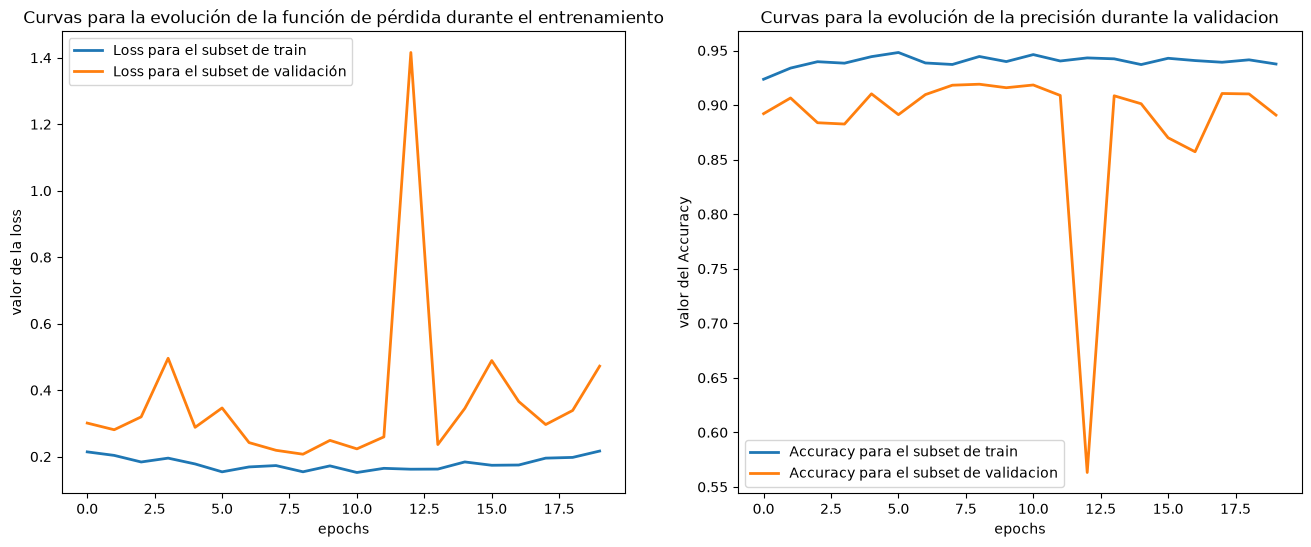

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_loss = [epoch["train"]["loss"] for epoch in history_head]
val_loss = [epoch["valid"]["loss"] for epoch in history_head]

train_accu = [epoch["train"]["accuracy"] for epoch in history_head]
val_accu = [epoch["valid"]["accuracy"] for epoch in history_head]


# Curva de la función de pérdida
axes[0].plot(train_loss, label='Loss para el subset de train', lw=2)
axes[0].plot(val_loss, label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()

# Curva de precisión
axes[1].plot(train_accu, label='Accuracy para el subset de train', lw=2)
axes[1].plot(val_accu, label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].legend()

In [ ]:
best_model_path = "uni_head_only_best.pt"

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()


UNIClassifier(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)


In [48]:
all_labels_train, all_preds_train = model_evaluation(train_loader, device, model)
print(classification_report(all_labels_train, all_preds_train)) 

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     24973
           1       0.98      0.92      0.95     25027

    accuracy                           0.95     50000
   macro avg       0.95      0.95      0.95     50000
weighted avg       0.95      0.95      0.95     50000



In [49]:
all_labels_val, all_preds_val = model_evaluation(val_loader, device, model)
print(classification_report(all_labels_val, all_preds_val)) 

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      4957
           1       0.98      0.83      0.90      5043

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



In [47]:
all_labels, all_preds = model_evaluation(test_loader, device, model)
print(classification_report(all_labels, all_preds)) 

              precision    recall  f1-score   support

           0       0.85      0.98      0.91     16391
           1       0.98      0.83      0.90     16377

    accuracy                           0.91     32768
   macro avg       0.92      0.91      0.91     32768
weighted avg       0.92      0.91      0.91     32768



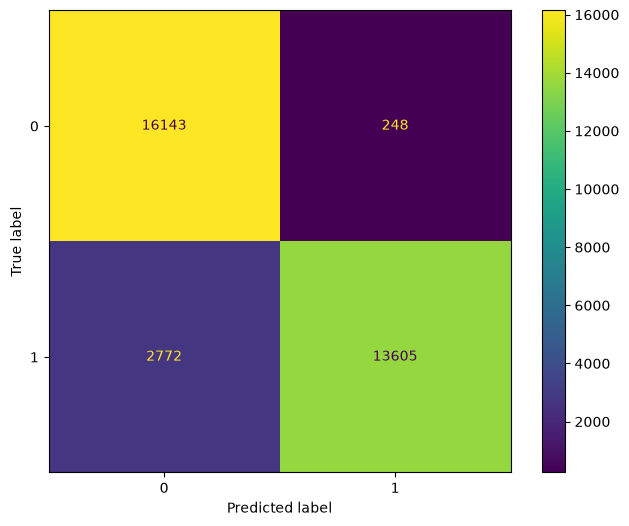

In [ ]:
matriz_confusion = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')

# UNI_2 Fine-tuning parcial del modelo

Descongelo las dos ultimas capas y aplicamos un scheduler que minimiza el learning rate de forma dinámica para tratar de que el modelo de menos saltos y
se desvíe de la dirección que minimiza la loss.

Partimos del modelo anterior guardado en "uni_head_only_best.pt"


In [15]:
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

In [17]:
best_model_path = "uni_head_only_best.pt"

model.load_state_dict(torch.load(best_model_path, map_location=device))

for param in model.encoder.parameters():
    param.requires_grad = False

for block in model.encoder.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

finetune_params = [param for param in model.parameters() if param.requires_grad]
finetune_optimizer = torch.optim.AdamW(finetune_params, lr=0.0001, weight_decay=0.01)

In [52]:
## Entrenamiento

In [ ]:
# El entrenamiento lo paramos manualmente porque por la observación de las métricas de cada epoch veíamos que se estaba sobreajustando
# a los datos de entrenamiento

best_val_auc = -float("inf")
best_finetuned_path =  "uni_finetuned_best.pt"
history_finetune = []
patience = 10
epochs_without_improvement = 0

for epoch in range(20):
    print(f"Starting finetune epoch {epoch + 1}/20...")
    train_metrics = run_epoch_images(model, train_loader, loss_selected, optimizer=finetune_optimizer, epoch_label=f"finetune train {epoch + 1}/20")
    valid_metrics = run_epoch_images(model, val_loader, loss_selected, epoch_label=f"finetune valid {epoch + 1}/20")
    history_finetune.append({"train": train_metrics, "valid": valid_metrics})

    print(
        f"Epoch {epoch + 1}/{20} de Finetuning| "
        f"train_loss={train_metrics['loss']:.4f} - train_acc={train_metrics['accuracy']:.4f} - train_recall={train_metrics['recall']:.4f} - train_auc={train_metrics['auc']:.4f} | "
        f"val_loss={valid_metrics['loss']:.4f} - val_acc={valid_metrics['accuracy']:.4f} - val_recall={valid_metrics['recall']:.4f} - val_auc={valid_metrics['auc']:.4f}"
    )

    if valid_metrics["auc"] > best_val_auc:
        best_val_auc = valid_metrics["auc"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_finetuned_path)
        print(f"Saved new best finetuned checkpoint to {best_finetuned_path} (val_auc={best_val_auc:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after epoch {epoch + 1}. Best val_auc={best_val_auc:.4f}")
        break

Starting finetune epoch 1/20...


finetune train 1/20:   0%|          | 0/391 [00:00<?, ?it/s]

finetune valid 1/20:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/20 de Finetuning| train_loss=0.0633 - train_acc=0.9788 - train_recall=0.9757 - train_auc=0.9970 | val_loss=0.3612 - val_acc=0.9079 - val_recall=0.8443 - val_auc=0.9663
Saved new best finetuned checkpoint to uni_finetuned_best.pt (val_auc=0.9663)
Starting finetune epoch 2/20...


finetune train 2/20:   0%|          | 0/391 [00:00<?, ?it/s]

...

finetune train 5/20:   0%|          | 0/391 [00:00<?, ?it/s]

finetune valid 5/20:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5/20 de Finetuning| train_loss=0.0095 - train_acc=0.9971 - train_recall=0.9966 - train_auc=0.9999 | val_loss=0.7457 - val_acc=0.8957 - val_recall=0.8065 - val_auc=0.9706
Starting finetune epoch 6/20...


finetune train 6/20:   0%|          | 0/391 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [53]:
## Evaluacion

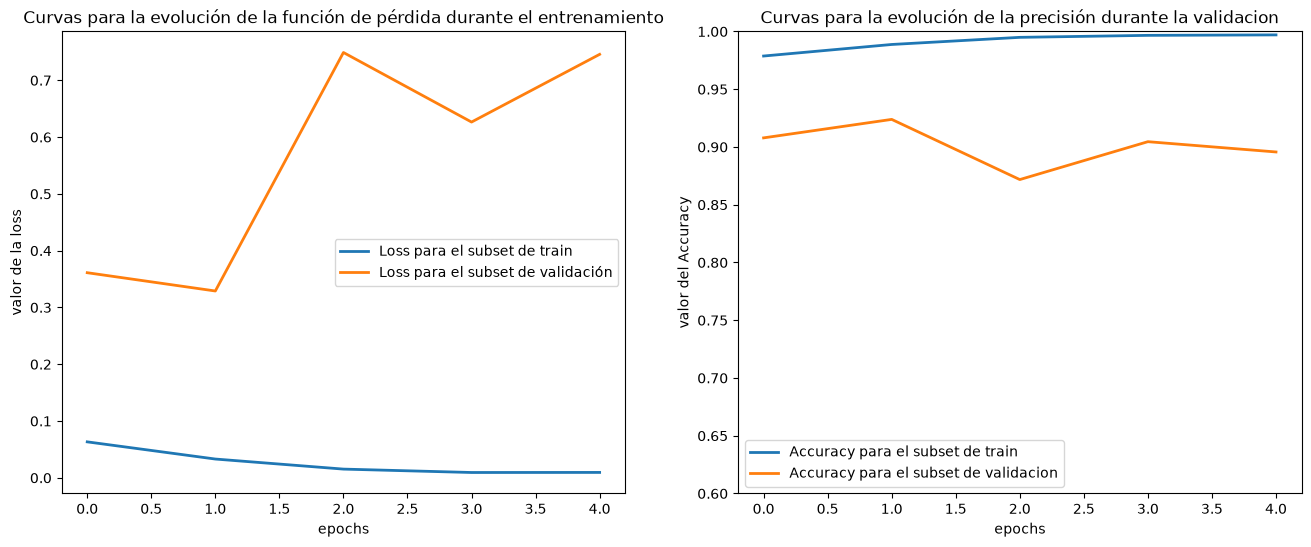

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_loss = [epoch["train"]["loss"] for epoch in history_finetune]
val_loss = [epoch["valid"]["loss"] for epoch in history_finetune]

train_accu = [epoch["train"]["accuracy"] for epoch in history_finetune]
val_accu = [epoch["valid"]["accuracy"] for epoch in history_finetune]


# Curva de la función de pérdida
axes[0].plot(train_loss, label='Loss para el subset de train', lw=2)
axes[0].plot(val_loss, label='Loss para el subset de validación', lw=2)
axes[0].set_title('Curvas para la evolución de la función de pérdida durante el entrenamiento')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('valor de la loss')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Curva de precisión
axes[1].plot(train_accu, label='Accuracy para el subset de train', lw=2)
axes[1].plot(val_accu, label='Accuracy para el subset de validacion', lw=2)
axes[1].set_title('Curvas para la evolución de la precisión durante la validacion')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('valor del Accuracy')
axes[1].set_ylim(0.6, 1)
axes[1].legend()

In [ ]:
best_model_path = "uni_finetuned_best.pt"
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

UNIClassifier(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)


In [ ]:
all_labels_train, all_preds_train = model_evaluation(train_loader, device, model)
print(classification_report(all_labels_train, all_preds_train))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00     25066
           1       1.00      0.99      1.00     24934

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



In [ ]:
all_labels_val, all_preds_val = model_evaluation(val_loader, device, model)
print(classification_report(all_labels_val, all_preds_val))


              precision    recall  f1-score   support

           0       0.85      0.99      0.91      4983
           1       0.98      0.82      0.90      5017

    accuracy                           0.90     10000
   macro avg       0.92      0.90      0.90     10000
weighted avg       0.92      0.90      0.90     10000



In [38]:
model.load_state_dict(torch.load(best_finetuned_path, map_location=device))
test_metrics = run_epoch_images(model, test_loader, loss_selected)
test_metrics

valid batches:   0%|          | 0/256 [00:00<?, ?it/s]

{'loss': 0.6192417362472042,
 'accuracy': 0.907135009765625,
 'recall': 0.8274409232460157,
 'auc': 0.9724506275731354}

In [ ]:
all_labels, all_preds = model_evaluation(test_loader, device, model)
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8735    0.9763    0.9220     16391
           1     0.9731    0.8585    0.9122     16377

    accuracy                         0.9174     32768
   macro avg     0.9233    0.9174    0.9171     32768
weighted avg     0.9233    0.9174    0.9171     32768



In [36]:
test_acc = accuracy_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_preds)

print("Test accuracy:", test_acc)
print("Test recall:", test_recall)
print("Test auc:", test_auc)

Test accuracy: 0.91741943359375
Test recall: 0.8584600354155217
Test auc: 0.917394254178995


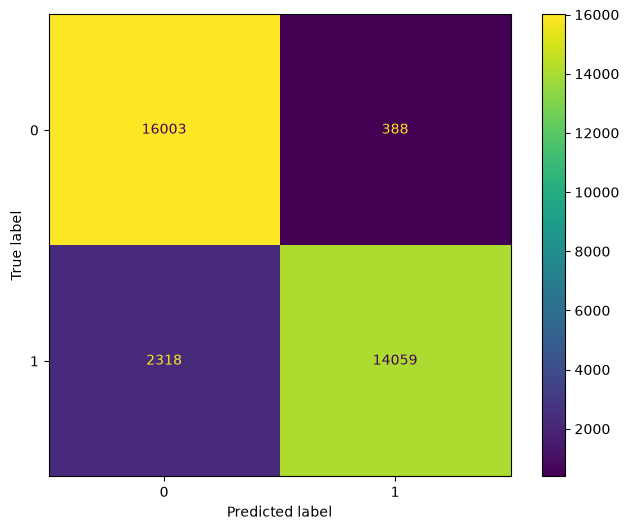

In [ ]:
matriz_confusion = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
cm_display.plot(ax=ax, values_format='d')